# Option Pricing Model Performance

This notebook covers the option pricing component of the wider GroupProject application. The full project also includes other modules such as house pricing, sentiment analysis, authentication, and portfolio features, but this notebook focuses only on the Nasdaq 100 futures option pricing workflow.

This is the final evaluation version of the option pricing notebook. It loads the compiled XGBoost model, rebuilds the held-out test split used during training, and reports performance against both the real option prices and the Black-76 benchmark.


Loading nasdaq_100_data.csv.gz...
Sigma is missing. Recomputing 30-day historical volatility from underlying prices...
Loaded 1,429,136 usable rows.
Columns used for evaluation:
['S', 'K', 'T', 'r', 'sigma', 'is_call', 'moneyness']

=== Option Pricing Model Performance ===
MAE:  $8.4388
RMSE: $23.7471
R²:   0.99972

=== Benchmark Comparison ===
Black-76 MAE: $118.3642
Error reduction vs Black-76: 92.87%


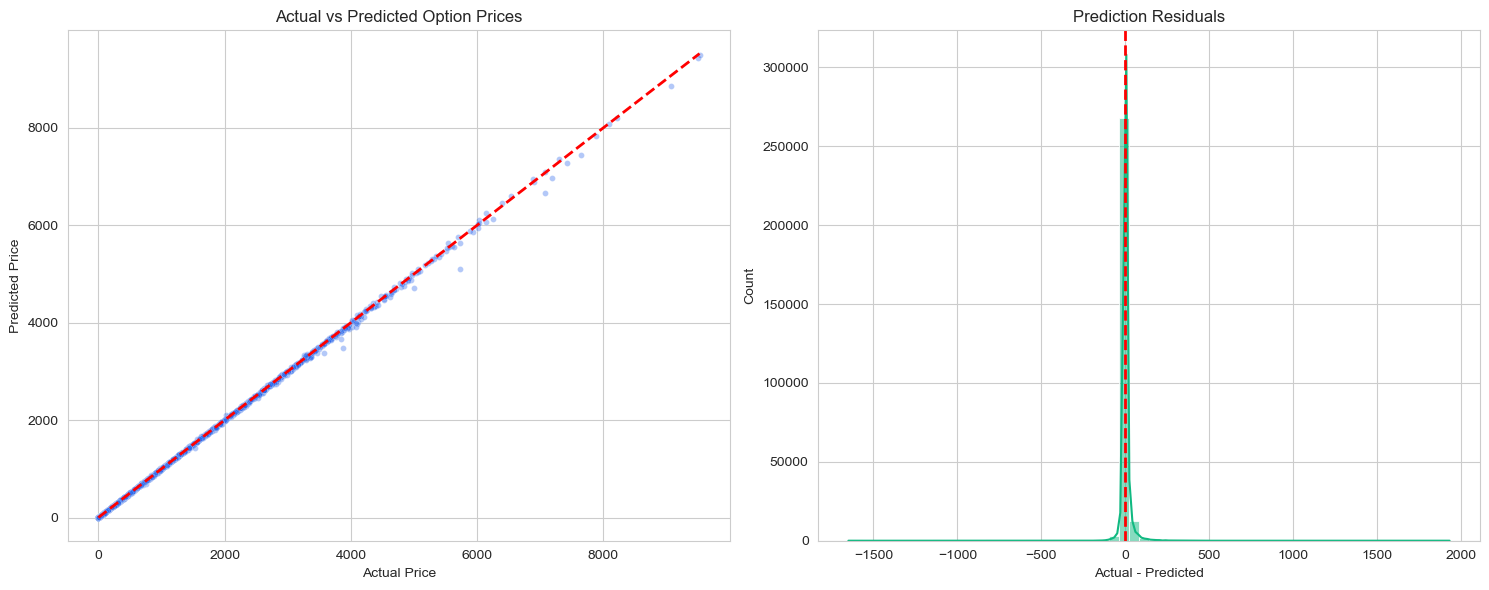

,Metric,Value
0,MAE,8.438758
1,RMSE,23.747088
2,R2,0.999719
3,Black-76 MAE,118.364150


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from scipy.stats import norm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

sns.set_style('whitegrid')

DATA_PATH = 'nasdaq_100_data.csv.gz'
MODEL_PATH = 'nasdaq_option_pricer.json'
FEATURES = ['S', 'K', 'T', 'r', 'sigma', 'is_call', 'moneyness']


def ensure_sigma(df: pd.DataFrame) -> pd.DataFrame:
    if 'sigma' in df.columns and df['sigma'].notna().any():
        df['sigma'] = pd.to_numeric(df['sigma'], errors='coerce')
        return df

    print('Sigma is missing. Recomputing 30-day historical volatility from underlying prices...')
    price_history = df[['date', 'S']].dropna().drop_duplicates().sort_values('date').copy()
    price_history['returns'] = np.log(price_history['S'] / price_history['S'].shift(1))
    price_history['sigma'] = price_history['returns'].rolling(window=30).std() * np.sqrt(252)
    price_history['sigma'] = price_history['sigma'].fillna(price_history['sigma'].mean())

    df = df.merge(price_history[['date', 'sigma']], on='date', how='left', suffixes=('', '_calculated'))
    if 'sigma_calculated' in df.columns:
        df['sigma'] = df['sigma'].fillna(df['sigma_calculated'])
        df = df.drop(columns=['sigma_calculated'])
    return df


def black_76(F, K, T, r, sigma, is_call):
    if F <= 0 or K <= 0 or T <= 0 or sigma <= 0:
        return np.nan

    vol_sqrt_t = sigma * np.sqrt(T)
    if vol_sqrt_t == 0:
        return np.nan

    d1 = (np.log(F / K) + 0.5 * sigma ** 2 * T) / vol_sqrt_t
    d2 = d1 - vol_sqrt_t
    discount = np.exp(-r * T)

    if is_call:
        return discount * (F * norm.cdf(d1) - K * norm.cdf(d2))
    return discount * (K * norm.cdf(-d2) - F * norm.cdf(-d1))


print(f'Loading {DATA_PATH}...')
df = pd.read_csv(DATA_PATH, compression='gzip')

if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

if 'optionType' in df.columns and 'is_call' not in df.columns:
    option_type = df['optionType'].astype(str).str.upper()
    df['is_call'] = option_type.apply(lambda value: 1 if value in {'C', 'CALL'} or value.endswith('C') or 'CALL' in value else 0)

if 'r' not in df.columns:
    df['r'] = 0.045
else:
    df['r'] = pd.to_numeric(df['r'], errors='coerce').fillna(0.045)

for column in ['S', 'K', 'T', 'marketPrice', 'is_call']:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors='coerce')

if 'moneyness' not in df.columns:
    df['moneyness'] = df['S'] / df['K']
else:
    df['moneyness'] = pd.to_numeric(df['moneyness'], errors='coerce')

if 'sigma' not in df.columns or df['sigma'].isna().any():
    df = ensure_sigma(df)

required_columns = FEATURES + ['marketPrice']
df = df.dropna(subset=required_columns).copy()
df = df[(df['K'] > 0) & (df['S'] > 0) & (df['T'] > 0)]

print(f'Loaded {len(df):,} usable rows.')
print('Columns used for evaluation:')
print(FEATURES)

X = df[FEATURES]
y_dollars = df['marketPrice']
y_log = np.log1p(y_dollars.clip(lower=0))

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42,
)

y_test_dollars = np.expm1(y_test_log)

booster = xgb.Booster()
booster.load_model(MODEL_PATH)

dtest = xgb.DMatrix(X_test, feature_names=FEATURES)
log_predictions = booster.predict(dtest)
predictions = np.expm1(log_predictions)

mae = mean_absolute_error(y_test_dollars, predictions)
rmse = np.sqrt(mean_squared_error(y_test_dollars, predictions))
r2 = r2_score(y_test_dollars, predictions)

benchmark_predictions = X_test.apply(
    lambda row: black_76(row['S'], row['K'], row['T'], row['r'], row['sigma'], row['is_call']),
    axis=1,
)
benchmark_predictions = benchmark_predictions.fillna(y_test_dollars.mean())
benchmark_mae = mean_absolute_error(y_test_dollars, benchmark_predictions)

print('\n=== Option Pricing Model Performance ===')
print(f'MAE:  ${mae:,.4f}')
print(f'RMSE: ${rmse:,.4f}')
print(f'R²:   {r2:.5f}')
print('')
print('=== Benchmark Comparison ===')
print(f'Black-76 MAE: ${benchmark_mae:,.4f}')
print(f'Error reduction vs Black-76: {(benchmark_mae - mae) / benchmark_mae * 100:.2f}%')

results = pd.DataFrame({
    'actual': y_test_dollars.reset_index(drop=True),
    'predicted': pd.Series(predictions),
    'benchmark': pd.Series(benchmark_predictions.values),
})
results['residual'] = results['actual'] - results['predicted']

sample_size = min(2000, len(results))
sample = results.sample(sample_size, random_state=42) if sample_size else results

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=sample, x='actual', y='predicted', alpha=0.35, s=18, ax=axes[0], color='#2563eb')
max_value = max(sample['actual'].max(), sample['predicted'].max()) if len(sample) else 1
axes[0].plot([0, max_value], [0, max_value], 'r--', linewidth=2)
axes[0].set_title('Actual vs Predicted Option Prices')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

sns.histplot(results['residual'], bins=60, kde=True, ax=axes[1], color='#10b981')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Prediction Residuals')
axes[1].set_xlabel('Actual - Predicted')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2', 'Black-76 MAE'],
    'Value': [mae, rmse, r2, benchmark_mae],
})
summary

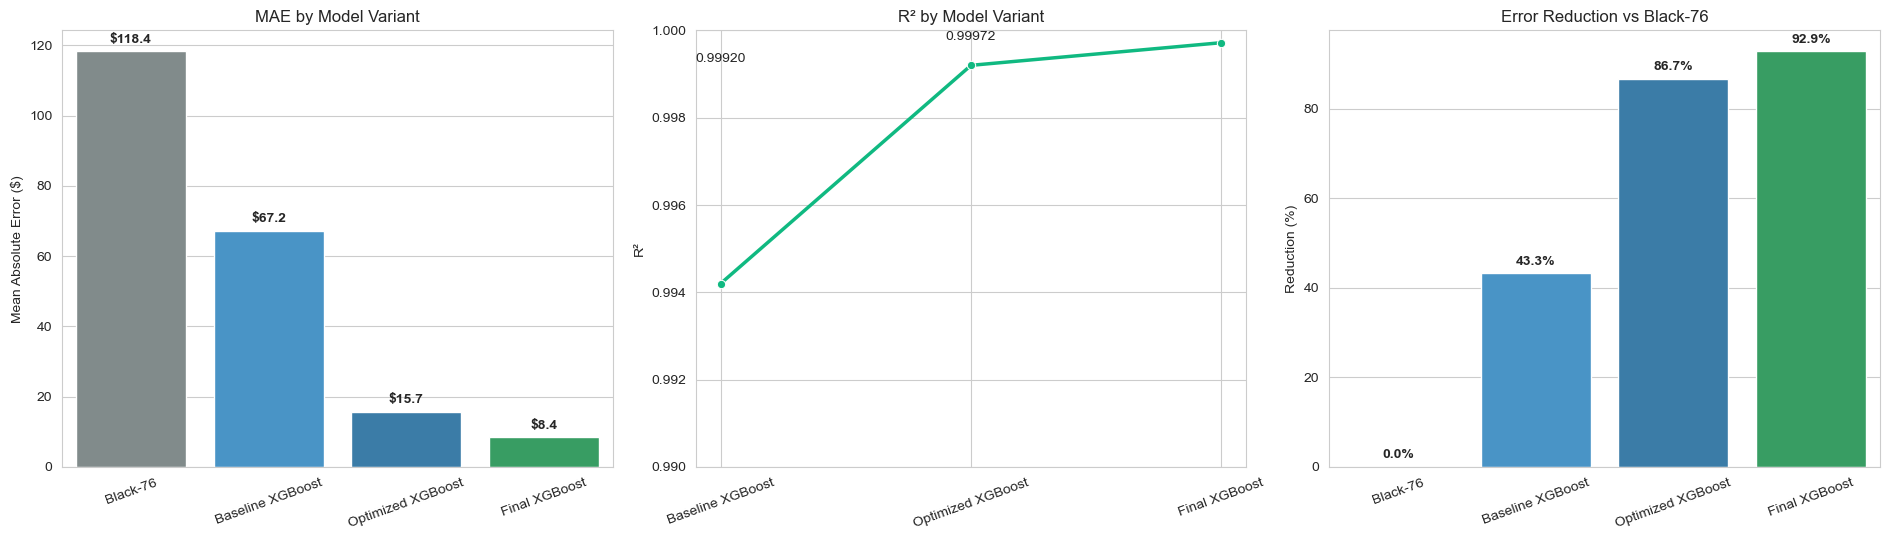

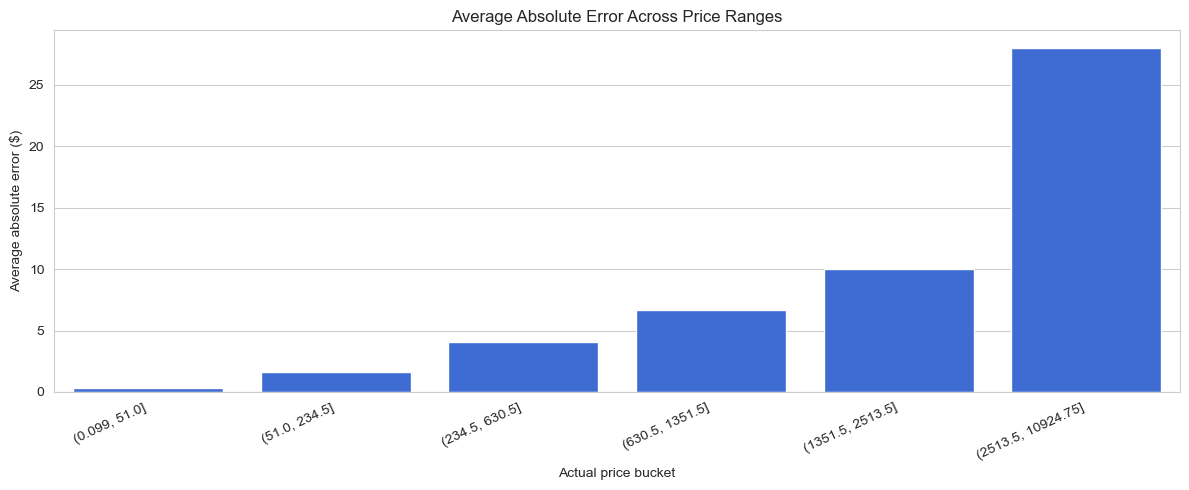

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

comparison_data = pd.DataFrame(
    {
        'Model': [
            'Black-76',
            'Baseline XGBoost',
            'Optimized XGBoost',
            'Final XGBoost',
        ],
        'MAE': [118.3642, 67.1634, 15.6961, 8.4388],
        'R2': [np.nan, 0.9942, 0.9992, 0.999719],
    }
)

benchmark_mae = comparison_data.loc[comparison_data['Model'] == 'Black-76', 'MAE'].iloc[0]
comparison_data['Error_Reduction_%'] = (benchmark_mae - comparison_data['MAE']) / benchmark_mae * 100
comparison_data.loc[comparison_data['Model'] == 'Black-76', 'Error_Reduction_%'] = 0.0

stage_order = ['Black-76', 'Baseline XGBoost', 'Optimized XGBoost', 'Final XGBoost']
comparison_data['Model'] = pd.Categorical(comparison_data['Model'], categories=stage_order, ordered=True)
comparison_data = comparison_data.sort_values('Model')

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

palette = ['#7f8c8d', '#3498db', '#2980b9', '#27ae60']
sns.barplot(
    data=comparison_data,
    x='Model',
    y='MAE',
    hue='Model',
    dodge=False,
    palette=palette,
    legend=False,
    ax=axes[0],
)
axes[0].set_title('MAE by Model Variant')
axes[0].set_xlabel('')
axes[0].set_ylabel('Mean Absolute Error ($)')
axes[0].tick_params(axis='x', rotation=20)
for patch in axes[0].patches:
    height = patch.get_height()
    axes[0].annotate(
        f'${height:.1f}',
        (patch.get_x() + patch.get_width() / 2, height),
        ha='center',
        va='bottom',
        xytext=(0, 4),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
    )

r2_data = comparison_data.dropna(subset=['R2'])
sns.lineplot(data=r2_data, x='Model', y='R2', marker='o', linewidth=2.5, ax=axes[1], color='#10b981')
axes[1].set_title('R² by Model Variant')
axes[1].set_xlabel('')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0.99, 1.0)
axes[1].tick_params(axis='x', rotation=20)
for x_index, value in enumerate(r2_data['R2']):
    axes[1].annotate(f'{value:.5f}', (x_index, value), ha='center', va='bottom', fontsize=10)

sns.barplot(
    data=comparison_data,
    x='Model',
    y='Error_Reduction_%',
    hue='Model',
    dodge=False,
    palette=palette,
    legend=False,
    ax=axes[2],
)
axes[2].set_title('Error Reduction vs Black-76')
axes[2].set_xlabel('')
axes[2].set_ylabel('Reduction (%)')
axes[2].tick_params(axis='x', rotation=20)
for patch in axes[2].patches:
    height = patch.get_height()
    axes[2].annotate(
        f'{height:.1f}%',
        (patch.get_x() + patch.get_width() / 2, height),
        ha='center',
        va='bottom',
        xytext=(0, 4),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
    )

plt.tight_layout()
plt.show()

abs_error = results.copy()
abs_error['abs_error'] = abs_error['residual'].abs()
abs_error['price_bucket'] = pd.qcut(abs_error['actual'], q=6, duplicates='drop')

bucket_summary = abs_error.groupby('price_bucket', observed=False).agg(
    avg_abs_error=('abs_error', 'mean'),
    avg_actual=('actual', 'mean')
).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=bucket_summary, x='price_bucket', y='avg_abs_error', color='#2563eb')
plt.title('Average Absolute Error Across Price Ranges')
plt.xlabel('Actual price bucket')
plt.ylabel('Average absolute error ($)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## What These Graphs Show

- **MAE by model variant** shows how the average dollar error changes as the model improves. The drop from Black-76 to baseline XGBoost, then to the optimized and final XGBoost versions, shows that the learned model is capturing the pricing structure much more effectively than the benchmark.
- **R² by model variant** shows how much of the variation in option prices each model explains. The closer the value is to 1, the better the fit. The final model is almost perfect on the held-out split, which is why this graph is useful for showing the effect of tuning.
- **Error reduction vs Black-76** shows the improvement relative to the pricing formula. This is the clearest graph for explaining the value of the machine-learning approach in the report because it translates the results into percentage gains.
- **Average absolute error across price ranges** shows where the model is strongest and where it struggles more. Smaller and mid-priced options are predicted more accurately, while higher-priced options tend to have larger absolute errors because they are harder to fit precisely.

For the report, these graphs work together as a model-selection story: the first two show overall performance, the third shows relative improvement, and the fourth shows how the model behaves across different price levels.

## Additional Performance Views

The next cell adds comparison graphs for the available model variants in this project: Black-76, baseline XGBoost, optimized XGBoost, and the final tuned model.


# Report Draft

This project investigates the pricing of E-mini Nasdaq 100 futures options as one component of the wider GroupProject application. The broader system also includes house pricing, sentiment analysis, authentication, and portfolio features, but this notebook focuses specifically on the option pricing workflow and the model used to support it.

The dataset used in this study was sourced from Nasdaq Data Link and covers the period from 2022 to 2024. This window is useful because it spans two very different market regimes: the 2022 technology-sector correction and the AI-driven rally of 2023 to 2024. Raw CME OptionWorks data was initially very large, with the filtered two-year extract reaching roughly 55 to 60 GB before refinement. To make the analysis tractable, the scope was narrowed to E-mini Nasdaq 100 futures options, producing a final modeling dataset of approximately two million observations.

Several feature engineering steps were required before model development. Core variables such as time to expiry ($T$), moneyness ($S/K$), and a call/put indicator were derived computationally. Because implied volatility was not available in the source data, $\sigma$ was proxied using 30-day historical volatility calculated from the underlying E-mini Nasdaq 100 futures returns, with the underlying price history merged from Yahoo Finance. This proxy was sufficient for feature construction and for comparing the model against the Black-76 benchmark, although it is an important limitation of the study.

Following exploratory data analysis, the dataset was prepared for supervised learning. The modeling process began with simpler ensemble approaches and then moved to XGBoost, which was selected as the primary model because it handled the large tabular dataset efficiently and delivered stronger predictive performance than the earlier alternatives. XGBoost was also a better fit for this problem than Random Forest because it can learn complex nonlinear relationships and feature interactions, apply regularization to control overfitting, and scale efficiently to a dataset with millions of observations. The final feature set consisted of underlying price, strike, time to expiry, risk-free rate, volatility proxy, call/put encoding, and moneyness.

The data was split into training and testing sets using an 80/20 split with a fixed random seed to ensure reproducibility. After initial experiments with a standard XGBoost regressor, the architecture was upgraded to a GPU-enabled model with greater tree depth and capacity. A log transform was applied to the target variable to stabilize the price scale and reduce the influence of extreme option values:

$y_{log} = \log(1 + y)$

Predictions were then transformed back to dollar prices using the inverse operation:

$\hat{y} = \exp(\hat{y}_{log}) - 1$

Hyperparameter optimisation was performed with Optuna. A study was created with the objective set to minimize mean absolute error on dollar-scale predictions, and 50 trials were run. The winning configuration used 2970 estimators, a learning rate of 0.038675427649369536, max depth of 14, subsample of 0.8297602954426249, colsample_bytree of 0.8939875735406672, reg_alpha of 0.010787020848250325, reg_lambda of 7.1975260948069915, histogram-based tree growth, CUDA acceleration, early stopping rounds set to 50, n_jobs = -1, and random_state = 42.

The final model achieved very strong performance on the held-out test split, with a mean absolute error of $8.4388 and $R^2 \approx 0.99972. The Black-76 benchmark, using historical volatility as the sigma input, produced a substantially larger error. This gap indicates that the model is capturing the structure present in the historical data very effectively, but the result should be interpreted carefully.

There are two important caveats. First, the evaluation uses a random train-test split rather than a forward-looking time-series split, so observations from the same market regime can appear in both sets. Second, the benchmark is weakened by the use of historical volatility instead of true implied volatility. As a result, the reported accuracy is best understood as strong historical fit rather than guaranteed live-market performance.

Overall, this option-pricing module demonstrates that a tuned XGBoost model can fit the historical CME option data very closely and outperform a basic Black-76 benchmark under the chosen evaluation setup. For a technical report, the most defensible framing is to present this as a successful machine-learning pricing experiment within the larger project, while explicitly acknowledging the limitations created by the volatility proxy and the random split.